# Main Easy

In [53]:
import math
import torch
from matplotlib import pyplot as plt
import numpy as np

# ----------------------------
# 1) Build your disordered ring J = K + J_dis  (symmetric, diag=0)
# ----------------------------
@torch.no_grad()
def make_ring_plus_disorder_J(
    N: int,
    threshold_active_fraction: float,
    g_disorder: float = 0.3,
    device: str = "cpu",
    seed: int | None = 0,
) -> torch.Tensor:
    """
    Returns W (N,N): structured local ring kernel + symmetric Gaussian disorder.
    Matches your construction:
      K_ij = 1/N if ring distance <= threshold else 0, with K_ii=0
      J_dis_ij ~ N(0, g^2/(2N)) symmetric, with zero diagonal
    """
    if seed is not None:
        torch.manual_seed(seed)

    idx = torch.arange(N, device=device)
    diff = (idx[:, None] - idx[None, :]).abs()
    diff = torch.minimum(diff, N - diff)

    thr = threshold_active_fraction * N / 2.0
    K = (diff <= thr).float() / N
    K.fill_diagonal_(0.0)

    R = torch.randn((N, N), device=device)
    R = torch.triu(R, diagonal=1)
    R = R + R.T
    R.fill_diagonal_(0.0)

    J_dis = (g_disorder / math.sqrt(2.0 * N)) * R

    W = K + J_dis
    W.fill_diagonal_(0.0)
    return W


# ----------------------------
# 2) Mean-field solver with activity constraint mean(rho)=f
#    Model: E(s) = -(c/2) s^T W s - c b^T s,  s_i in {0,1}
#    Mean-field equation: rho = sigmoid( (c W rho + c b - eta)/T )
#    with eta chosen so mean(rho)=f
# ----------------------------
@torch.no_grad()
def solve_mean_field_fixed_activity(
    W: torch.Tensor,      # (N,N) symmetric
    b: torch.Tensor,      # (N,) external drive (your bump)
    T: float,             # temperature (sigma_temp)
    f: float,             # target active fraction
    c: float,             # coupling scale (ampar_conductance * input_resistance)
    max_iter: int = 500,
    tol: float = 1e-6,
    damping: float = 0.2,         # 0.1–0.5 typically
    eta_bisect_steps: int = 60,   # plenty for float32/64
) -> tuple[torch.Tensor, float]:
    """
    Returns:
      rho (N,) : mean-field estimate of <s_i>
      eta      : Lagrange multiplier enforcing mean(rho)=f
    """
    assert W.ndim == 2 and W.shape[0] == W.shape[1]
    N = W.shape[0]
    device = W.device
    b = b.to(device)

    # Start from uniform activity
    rho = torch.full((N,), float(f), device=device)

    for _ in range(max_iter):
        # Mean recurrent input under MF: h = W rho
        h = W @ rho

        # "raw field" x_i = c h_i + b_i
        x = c * (h + b)

        # Need eta so that mean(sigmoid((x - eta)/T)) = f
        # This is monotone in eta, so bisection is safe.

        # Bracket eta using x-range; +/- 20*T makes sigmoid saturate.
        eta_lo = (x.min() - 20.0 * T).item()
        eta_hi = (x.max() + 20.0 * T).item()

        def mean_rho(eta: float) -> float:
            return torch.sigmoid((x - eta) / T).mean().item()

        # Bisection
        for _ in range(eta_bisect_steps):
            eta_mid = 0.5 * (eta_lo + eta_hi)
            if mean_rho(eta_mid) > f:
                eta_lo = eta_mid
            else:
                eta_hi = eta_mid
        eta = 0.5 * (eta_lo + eta_hi)

        rho_new = torch.sigmoid((x - eta) / T)

        # Damped update (helps convergence a lot)
        rho_next = (1.0 - damping) * rho + damping * rho_new

        # Convergence check
        if (rho_next - rho).abs().max().item() < tol:
            rho = rho_next
            break

        rho = rho_next

    return rho, float(eta)


# ----------------------------
# 3) A tiny helper to make a bump on a ring
# ----------------------------
@torch.no_grad()
def ring_gaussian_bump(N: int, center: float, width: float, amp: float, device="cpu") -> torch.Tensor:
    """
    center in [0, N), width in neuron-index units.
    Uses periodic distance on the ring.
    """
    idx = torch.arange(N, device=device).float()
    d = (idx - center).abs()
    d = torch.minimum(d, N - d)
    return amp * torch.exp(-0.5 * (d / width) ** 2)



def compute_norm_difference(N, W, T, f, c, width, amp, device):
    # Two stimuli (two bump centers)
    b1 = ring_gaussian_bump(N, center=100.0, width=width, amp=amp, device=device)
    b2 = ring_gaussian_bump(N, center=105.0, width=width, amp=amp, device=device)

    mu1, eta1 = solve_mean_field_fixed_activity(W, b1, T=T, f=f, c=c)
    mu2, eta2 = solve_mean_field_fixed_activity(W, b2, T=T, f=f, c=c)

    dmu = mu1 - mu2

    # print("mean(mu1) =", mu1.mean().item(), " eta1 =", eta1)
    # print("mean(mu2) =", mu2.mean().item(), " eta2 =", eta2)
    # print("||Delta mu||_2 =", dmu.norm().item())
    return dmu.norm().item()


@torch.no_grad()
def Chi_eq_from_s(W: torch.Tensor, s: torch.Tensor, T: float, c: float,
                    eps: float = 1e-8) -> torch.Tensor:
    """
    Equilibrium/FDT covariance :
    """
    N = W.shape[0]
    device = W.device

    D_matrix = torch.diag(s)
    M = torch.eye(N, device=device) - c * (D_matrix@ W)
    X = torch.linalg.solve(M, D_matrix)     # (I-M)^{-1} D
    return X

@torch.no_grad()
def lam_max_effective(W: torch.Tensor, rho: torch.Tensor, T: float, c: float, eps: float = 1e-12):
    s = rho*(1-rho)/T
    sd = torch.sqrt(torch.clamp(s, min=0.0))
    Sd = torch.diag(sd)
    M = c * (Sd @ W @ Sd)
    return float(torch.linalg.eigvalsh(0.5*(M+M.T)).max().item())

# ============================================================
# 3) Alignment diagnostic
# ============================================================

@torch.no_grad()
def topk_alignment(Sigma: torch.Tensor, dmu: torch.Tensor, k: int = 10) -> float:
    """Fraction of ||dmu||^2 in top-k eigenmodes of Sigma."""
    S = 0.5 * (Sigma + Sigma.T)
    evals, evecs = torch.linalg.eigh(S)  # ascending
    evecs = evecs[:, torch.arange(evecs.shape[1]-1, -1, -1, device=evecs.device)]
    d = dmu / (dmu.norm() + 1e-12)
    coeff = evecs.T @ d
    return float((coeff[:k] ** 2).sum().item())

# ============================================================
# 4) CTR vs FR comparison (clean output dict)
# ============================================================

@torch.no_grad()
def compare_ctr_fr_once(
    N, W, T,
    f_ctr, c_ctr,
    f_fr,  c_fr,
    width, amp, device,
    k_align: int = 10,
    eps: float = 1e-8,
):
    # stimuli
    b1 = ring_gaussian_bump(N, center=100.0, width=width, amp=amp, device=device)
    b2 = ring_gaussian_bump(N, center=102.0, width=width, amp=amp, device=device)

    # MF means
    mu1c, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_ctr, c=c_ctr)
    mu2c, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_ctr, c=c_ctr)
    dmu_c = mu1c - mu2c
    dmu_norm_c = dmu_c.norm().item()
    mu1f, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_fr, c=c_fr)
    mu2f, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_fr, c=c_fr)
    dmu_f = mu1f - mu2f
    dmu_norm_f = dmu_f.norm().item()

    # slopes
    s_ctr = (mu1c)*(1-mu1c)/T
    s_fr  = (mu1f)*(1-mu1f)/T

    # Σ_eq + counterfactuals
    Sig_ctr    = T*Chi_eq_from_s(W, s_ctr, T, c_ctr, eps=eps)
    Sig_fr     = T*Chi_eq_from_s(W, s_fr,  T, c_fr,  eps=eps)

    tr_eq_c      = float(torch.trace(Sig_ctr).item())
    tr_eq_f      = float(torch.trace(Sig_fr).item())

    # Participation ratio of evals of Sigma
    evals_ctr = torch.linalg.eigvalsh(Sig_ctr)
    pr_ctr = float((evals_ctr.sum() ** 2 / (evals_ctr ** 2).sum()).item())
    evals_fr = torch.linalg.eigvalsh(Sig_fr)
    pr_fr = float((evals_fr.sum() ** 2 / (evals_fr ** 2).sum()).item())

    dmu_norm_est_fr = float((c_fr*(Sig_fr/T) @ (b1-b2)).norm().item())
    dmu_norm_est_ctr = float((c_ctr*(Sig_ctr/T) @ (b1-b2)).norm().item())
    print(f"||Δμ||_2 estimate from linear response: ctr={dmu_norm_est_ctr:.2f} vs actual {dmu_norm_c:.2f} | "
          f"fr={dmu_norm_est_fr:.2f} vs actual {dmu_norm_f:.2f}")
    
    # plt.hist(c_ctr*evals_ctr/T, density=True, bins=50, label="CTR")
    # plt.axvline(x= torch.mean(c_ctr*evals_ctr/T), color='blue', linestyle='dashed', linewidth=1)
    # plt.hist(c_fr*evals_fr/T, density=True, bins=50, alpha=0.7, label="FR")
    # plt.axvline(x= torch.mean(c_fr*evals_fr/T), color='orange', linestyle='dashed', linewidth=1)
    # plt.legend()
    # plt.xlabel("Eigenvalues")
    # plt.ylabel("Density")
    # plt.title("Distribution of Eigenvalues")
    # plt.show()

    # gain margin
    lam_c = lam_max_effective(W, mu1c, T=T, c=c_ctr)
    lam_f = lam_max_effective(W, mu1f, T=T, c=c_fr)

    return dict(
        Dmean_ctr=float(s_ctr.mean().item()),
        Dmean_fr=float(s_fr.mean().item()),
        lam_ctr=lam_c, lam_fr=lam_f,
        trSigma_eq_ctr=tr_eq_c,
        trSigma_eq_fr=tr_eq_f,
        align_eq_top10_ctr=topk_alignment(Sig_ctr, dmu_c, k=k_align),
        align_eq_top10_fr=topk_alignment(Sig_fr, dmu_f, k=k_align),
        pr_eq_ctr=pr_ctr,
        pr_eq_fr=pr_fr,
        dmu_norm_ctr=dmu_norm_c,
        dmu_norm_fr=dmu_norm_f,
        mean_eval_fr=float(evals_fr.mean().item()),
        mean_eval_ctr=float(evals_ctr.mean().item())
    )



In [54]:
if __name__ == "__main__":
    device = "cpu"
    N = 200
    thr_frac = 0.05         
    amp = 0.03
    width = thr_frac*N/2
    f = 0.1                # target active fraction

    g_dis = 0            # disorder strength
    W = 2*make_ring_plus_disorder_J(N, thr_frac, g_disorder=g_dis, device=device, seed=0)

    f_ctr = f*1
    c_fr = 0.64*1.27
    f_fr = f*1.3
    c_ctr  = 1.0*1.0

    for T in [0.005,0.01,0.03,0.05,0.08,0.1]:
        # print(f"Temperature T={T}:")
        # norm_diff_ctr = compute_norm_difference(N, W, T, f_ctr, c_ctr, width=width, amp=amp, device=device)
        # norm_diff_fr = compute_norm_difference(N, W, T, f_fr, c_fr, width=width, amp=amp, device=device)
        # print( norm_diff_ctr/norm_diff_fr )
        # print("-" * 30)

        stats = compare_ctr_fr_once(
        N=N, W=W, T=T,
        f_ctr=f, c_ctr=c_ctr,
        f_fr=f,  c_fr=c_fr,
        width=width, amp=amp, device=device,
        k_align=10,
        )
        print(
            f"T={T:.3f}  | "
            f"Dmean(ctr,fr)=({stats['Dmean_ctr']:.3f},{stats['Dmean_fr']:.3f}) | "
            f"lam_max(ctr,fr)=({stats['lam_ctr']:.3f},{stats['lam_fr']:.3f}) "
            f"tr(Sigma_eq)(ctr,fr)=({stats['trSigma_eq_ctr']:.2f},{stats['trSigma_eq_fr']:.2f}) | "
            f"align_eq_top10(ctr,fr)=({stats['align_eq_top10_ctr']:.2f},{stats['align_eq_top10_fr']:.2f})"
            f"pr_eq(ctr,fr)=({stats['pr_eq_ctr']:.2f},{stats['pr_eq_fr']:.2f})"
            f"||Δμ||_2(ctr,fr)=({stats['dmu_norm_ctr']:.2f},{stats['dmu_norm_fr']:.2f})"
            f"mean_eval(ctr,fr)=({stats['mean_eval_ctr']:.3f},{c_fr*stats['mean_eval_fr']:.3f})"
        )

||Δμ||_2 estimate from linear response: ctr=1.59 vs actual 1.39 | fr=1.46 vs actual 1.31
T=0.005  | Dmean(ctr,fr)=(1.149,1.369) | lam_max(ctr,fr)=(0.816,0.822) tr(Sigma_eq)(ctr,fr)=(2.33,2.62) | align_eq_top10(ctr,fr)=(0.98,0.96)pr_eq(ctr,fr)=(3.43,3.89)||Δμ||_2(ctr,fr)=(1.39,1.31)mean_eval(ctr,fr)=(0.012,0.011)
||Δμ||_2 estimate from linear response: ctr=1.18 vs actual 1.11 | fr=1.06 vs actual 1.02
T=0.010  | Dmean(ctr,fr)=(1.361,2.133) | lam_max(ctr,fr)=(0.816,0.794) tr(Sigma_eq)(ctr,fr)=(3.96,5.35) | align_eq_top10(ctr,fr)=(0.93,0.95)pr_eq(ctr,fr)=(8.25,16.69)||Δμ||_2(ctr,fr)=(1.11,1.02)mean_eval(ctr,fr)=(0.020,0.022)
||Δμ||_2 estimate from linear response: ctr=0.21 vs actual 0.20 | fr=0.12 vs actual 0.12
T=0.030  | Dmean(ctr,fr)=(2.934,2.974) | lam_max(ctr,fr)=(0.568,0.388) tr(Sigma_eq)(ctr,fr)=(17.93,18.00) | align_eq_top10(ctr,fr)=(0.93,0.90)pr_eq(ctr,fr)=(169.73,187.80)||Δμ||_2(ctr,fr)=(0.20,0.12)mean_eval(ctr,fr)=(0.090,0.073)
||Δμ||_2 estimate from linear response: ctr=0.07 vs

--------------------------------------------------
Temperature T=0.01:
lam_max: ctr,fr=0.778,0.792
Mean Gamma Eval ctr,fr=1.098,1.590
Pr Gamma Eval: ctr,fr=21.29,32.45
Overlap of dx with top eigenvector: ctr=-0.030, fr=0.019
CV of ai^2 = 2.225857734680176
CV of ai^2 FR = 2.137545347213745


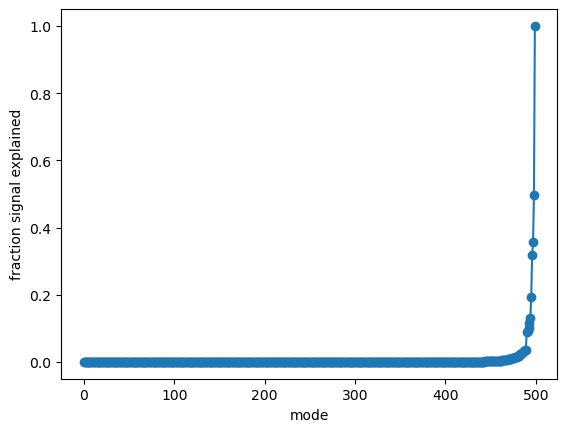

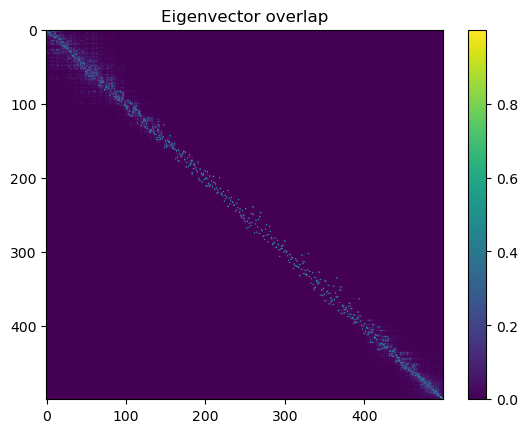

Mean eigenvector overlap: 0.16388359665870667
(c * zfr,z_ctr)**2 = 1.386
Ratio Actual Dmu norms (FR/CTR) = 0.912
Ratio LR Dmu norms (FR/CTR) = 0.889
||Δμ||_2 estimate CTR|| LR 0.21,act 0.21 | FR|| LR 0.19,act 0.19
True signal ratio = tensor(0.8886)
--------------------------------------------------
Temperature T=0.03:
lam_max: ctr,fr=1.168,1.065
Mean Gamma Eval ctr,fr=2.584,3.046
Pr Gamma Eval: ctr,fr=119.22,114.50
Overlap of dx with top eigenvector: ctr=-0.048, fr=-0.008
CV of ai^2 = 3.0546889305114746
CV of ai^2 FR = 3.133669853210449


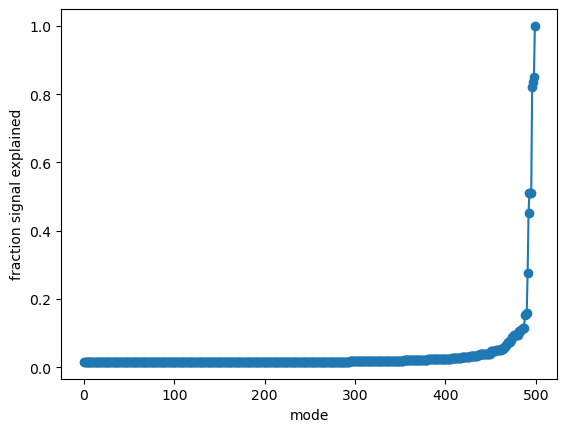

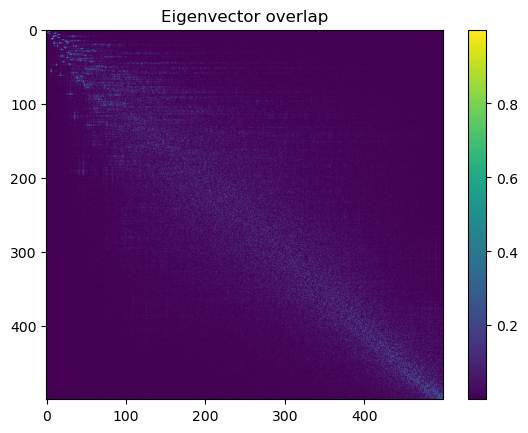

Mean eigenvector overlap: 0.08636694401502609
(c * zfr,z_ctr)**2 = 0.918
Ratio Actual Dmu norms (FR/CTR) = 0.724
Ratio LR Dmu norms (FR/CTR) = 0.845
||Δμ||_2 estimate CTR|| LR 0.30,act 0.29 | FR|| LR 0.25,act 0.21
True signal ratio = tensor(0.8454)
--------------------------------------------------
Temperature T=0.08:
lam_max: ctr,fr=0.336,0.266
Mean Gamma Eval ctr,fr=1.151,1.142
Pr Gamma Eval: ctr,fr=469.93,480.91
Overlap of dx with top eigenvector: ctr=-0.025, fr=0.004
CV of ai^2 = 2.264240264892578
CV of ai^2 FR = 2.4161689281463623


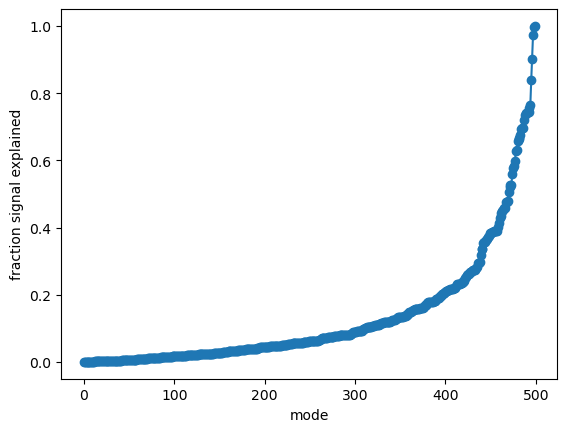

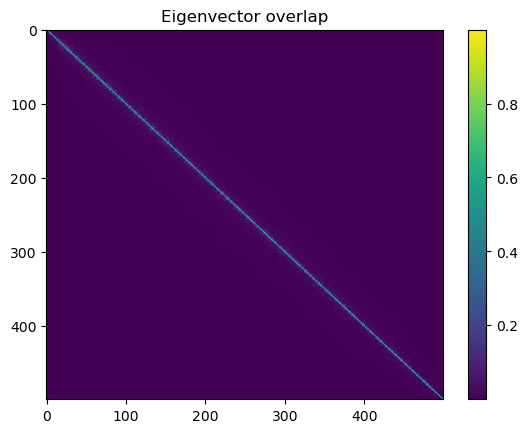

Mean eigenvector overlap: 0.7877419590950012
(c * zfr,z_ctr)**2 = 0.650
Ratio Actual Dmu norms (FR/CTR) = 0.754
Ratio LR Dmu norms (FR/CTR) = 0.754
||Δμ||_2 estimate CTR|| LR 0.03,act 0.03 | FR|| LR 0.03,act 0.03
True signal ratio = tensor(0.7536)


In [102]:
def compare_ctr_fr_evals(
    N, W, T,
    f_ctr, c_ctr,
    f_fr,  c_fr,
    width, amp, dtheta,device,
    eps: float = 1e-8,
):
    # stimuli
    b1 = ring_gaussian_bump(N, center=100.0, width=width, amp=amp, device=device)
    b2 = ring_gaussian_bump(N, center=(100+dtheta), width=width, amp=amp, device=device)
    dx = (b1-b2)
    # MF means
    mu1c, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_ctr, c=c_ctr)
    mu2c, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_ctr, c=c_ctr)
    
 

    mu1f, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_fr, c=c_fr)
    mu2f, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_fr, c=c_fr)
    
    # gain margin
    lam_c = lam_max_effective(W, mu1c, T=T, c=c_ctr)
    lam_f = lam_max_effective(W, mu1f, T=T, c=c_fr)
    print(f"lam_max: ctr,fr={lam_c:.3f},{lam_f:.3f}")


    # slopes
    s_ctr = (mu1c)*(1-mu1c)/T
    s_fr  = (mu1f)*(1-mu1f)/T

    # Gamma matrices and evals
    Gamma_ctr    = Chi_eq_from_s(W, s_ctr, T, c_ctr, eps=eps)
    Gamma_fr     = Chi_eq_from_s(W, s_fr,  T, c_fr,  eps=eps)

    evals_ctr,evecs_ctr = torch.linalg.eigh(Gamma_ctr)
    evals_fr,evecs_fr = torch.linalg.eigh(Gamma_fr)

    # Output change to mean Evalue
    print(f"Mean Gamma Eval ctr,fr={evals_ctr.mean().item():.3f},{evals_fr.mean().item():.3f}")


    # Participation ratio of evals of Sigma
    pr_ctr = float((evals_ctr.sum() ** 2 / (evals_ctr ** 2).sum()).item())
    pr_fr = float((evals_fr.sum() ** 2 / (evals_fr ** 2).sum()).item())

    print(f"Pr Gamma Eval: ctr,fr={pr_ctr:.2f},{pr_fr:.2f}")

    # Check if evectors are the same 
    # if torch.allclose(evecs_ctr, evecs_fr, atol=1e-5):
    #     print("Eigenvectors of Gamma are approximately the same for CTR and FR.")
    # # Norm of Signal Vector and its linear response estimate

    overlap_fr = torch.sum(evecs_fr.T @ dx).item()
    overlap_ctr = torch.sum(evecs_ctr.T @ dx).item()
    print(f"Overlap of dx with top eigenvector: ctr={overlap_ctr:.3f}, fr={overlap_fr:.3f}")
    ai2 = (evecs_ctr.T @ dx)**2
    cv = ai2.std() / ai2.mean()
    print("CV of ai^2 =", cv.item())
    ai2_fr = (evecs_fr.T @ dx)**2
    cv_fr = ai2_fr.std() / ai2_fr.mean()
    print("CV of ai^2 FR =", cv_fr.item())
    ai2 = (evecs_ctr.T @ dx)**2
    signal_modes = (evals_ctr**2) * ai2

    cum = torch.cumsum(signal_modes, dim=0) / signal_modes.sum()

    plt.plot(cum.cpu(), "o-")
    plt.ylabel("fraction signal explained")
    plt.xlabel("mode")
    plt.show()


    O = torch.abs(evecs_ctr.T @ evecs_fr)
    plt.imshow(O.cpu(), aspect='auto')
    plt.colorbar()
    plt.title("Eigenvector overlap")
    plt.show()
    diag_overlap = torch.abs(torch.sum(evecs_ctr * evecs_fr, dim=0))
    print("Mean eigenvector overlap:", diag_overlap.mean().item())

    dmu_c = mu1c - mu2c
    dmu_norm_c = dmu_c.norm().item()
    dmu_f = mu1f -   mu2f
    dmu_norm_f = dmu_f.norm().item()
    dmu_norm2_est_fr = float((c_fr*Gamma_fr @ dx).norm().item())
    dmu_norm2_est_ctr = float((c_ctr*Gamma_ctr @ dx).norm().item())
    print(f"(c * zfr,z_ctr)**2 = {(c_fr*evals_fr.mean().item()/evals_ctr.mean().item())**2:.3f}")
    print(f"Ratio Actual Dmu norms (FR/CTR) = {dmu_norm_f/dmu_norm_c:.3f}")
    print(f"Ratio LR Dmu norms (FR/CTR) = {dmu_norm2_est_fr/dmu_norm2_est_ctr:.3f}")
    print(f"||Δμ||_2 estimate CTR|| LR {dmu_norm2_est_ctr:.2f},act {dmu_norm_c:.2f} | "
          f"FR|| LR {dmu_norm2_est_fr:.2f},act {dmu_norm_f:.2f}")
    proj_ctr = (evecs_ctr.T @ dx)**2
    proj_fr  = (evecs_fr.T @ dx)**2

    signal_ctr = torch.sum((evals_ctr**2) * proj_ctr)
    signal_fr  = torch.sum((evals_fr**2) * proj_fr)

    print("True signal ratio =", (c_fr**2 * signal_fr / (c_ctr**2 * signal_ctr)).sqrt())
    # plt.plot((evecs_ctr.T @ dx)**2)
    # plt.plot((evecs_fr.T @ dx)**2)
    # plt.show()
    # plt.plot((evals_ctr**2) * proj_ctr)
    # plt.plot((evals_fr**2) * proj_fr)
    # plt.show()

device = "cpu"
N = 500
thr_frac = 0.1         
amp = 0.03
f = 0.1 
wrec = 1.0               # target active fraction
dtheta = 4


width = thr_frac*N/2
W = wrec*make_ring_plus_disorder_J(N, thr_frac, g_disorder=0.2, device=device, seed=0)
# W = 20*make_embedded_ring_J(
#         N,
#         rank_noise=30,
#         lam_ring=1.0,
#         lam_noise=1,
#         device=device,
#         seed=0
# )
f_ctr = f
c_fr = 0.64*1.27
f_fr = f
c_ctr  = 1.0

for T in [0.01,0.03,0.08]:
    print("-" * 50)
    print(f"Temperature T={T}:")

    stats = compare_ctr_fr_evals(
    N=N, W=W, T=T,
    f_ctr=f, c_ctr=c_ctr,
    f_fr=f,  c_fr=c_fr,
    width=width, amp=amp,dtheta = dtheta, device=device
    )

In [91]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Trial correlation factor for averaging (OU across trials)
# -----------------------------
@torch.no_grad()
def mean_variance_factor_correlated_trials(L: int, tau_trials: float, device="cpu") -> float:
    """
    fac(L,tau) = 1 + 2 sum_{k=1}^{L-1} (1-k/L) exp(-k/tau)
    Var(mean) = (Var_per_trial / L) * fac
    """
    if L <= 1:
        return 1.0
    if tau_trials <= 0:
        return 1.0
    ks = torch.arange(1, L, device=device, dtype=torch.float32)
    rho = torch.exp(-ks / float(tau_trials))
    weights = 1.0 - ks / float(L)
    fac = 1.0 + 2.0 * torch.sum(weights * rho)
    return float(fac.item())

# -----------------------------
# Build trial-mean covariance: Sigma_mean = Sigma/L + (fac/L) * alpha * Sigma^2
# -----------------------------
@torch.no_grad()
def build_total_cov_mean(Chi_eq: torch.Tensor, c: float, T: float,
                         sig_theta: float, L: int, tau_theta_trials: float):
    """
    per-trial:  Sigma_slow = alpha * Sig_eq^2  with alpha=(c*sig_theta/T)^2
    mean over L correlated trials: multiply by fac/L
    """
    device = Chi_eq.device
    alpha = (c * sig_theta) ** 2
    fac = mean_variance_factor_correlated_trials(L, tau_theta_trials, device=device)

    Sig_fast_mean = T*Chi_eq / float(L)
    Sig_slow_mean = (fac / float(L)) * alpha * (Chi_eq @ Chi_eq.T)

    COV_mean = Sig_fast_mean + Sig_slow_mean
    return COV_mean, alpha, fac

# -----------------------------
# One CTR/FR evaluation with the SHARED eigenbasis fix
# -----------------------------
@torch.no_grad()
def compare_ctr_fr_quadratic_L_sharedbasis(
    N, W, T,
    f_ctr, c_ctr,
    f_fr,  c_fr,
    width, amp, device,
    sig_theta: float,
    L: int,
    tau_theta_trials: float,
    dtheta: float,
    eps: float = 1e-8,
    use_linear_response_dmu: bool = True,   # recommended for the mechanism unit test
):
    W = W.to(device)

    # stimuli
    b1 = ring_gaussian_bump(N, center=100.0, width=width, amp=amp, device=device)
    b2 = ring_gaussian_bump(N, center=100+dtheta, width=width, amp=amp, device=device)
    db = b1 - b2

    # MF means
    mu1c, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_ctr, c=c_ctr)
    mu2c, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_ctr, c=c_ctr)
    mu1f, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_fr,  c=c_fr)
    mu2f, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_fr,  c=c_fr)

    dmu_c_mf = mu1c - mu2c
    dmu_f_mf = mu1f - mu2f

    # slopes -> Sigma_eq
    s_ctr = mu1c * (1 - mu1c) / T
    s_fr  = mu1f * (1 - mu1f) / T

    Chi_ctr = Chi_eq_from_s(W, s_ctr, T, c_ctr, eps=eps)
    Chi_fr  = Chi_eq_from_s(W, s_fr,  T, c_fr,  eps=eps)

    # linear-response "unit test" dmu
    dmu_c_lin = (c_ctr) * (Chi_ctr @ db)
    dmu_f_lin = (c_fr) * (Chi_fr  @ db)

    dmu_c = dmu_c_lin if use_linear_response_dmu else dmu_c_mf
    dmu_f = dmu_f_lin if use_linear_response_dmu else dmu_f_mf

    # trial-mean covariances
    COV_ctr, alpha_ctr, fac_ctr = build_total_cov_mean(Chi_ctr, c_ctr, T, sig_theta, L, tau_theta_trials)
    COV_fr,  alpha_fr,  fac_fr  = build_total_cov_mean(Chi_fr,  c_fr,  T, sig_theta, L, tau_theta_trials)

    # ---- SNR per mode ---#
    eval_c, evec_c = torch.linalg.eigh(0.5*(COV_ctr + COV_ctr.T))  # symmetrize for stability
    eval_f, evec_f = torch.linalg.eigh(0.5*(COV_fr  + COV_fr.T))
    snr_ctr =torch.full((N,), float('nan'), device=device)
    snr_fr = torch.full((N,), float('nan'), device=device)

    for i in range(N):
        v_c= evec_c[:, i:i+1]
        snr_ctr[i] = (dmu_c.T @ v_c).item() ** 2 / eval_c[i].item()

        v_f = evec_f[:, i:i+1]
        snr_fr[i] = (dmu_f.T @ v_f).item() ** 2 / eval_f[i].item()
    
    snr_fr = snr_fr.flip(0)  # reverse to match the order of evals (descending)
    snr_ctr = snr_ctr.flip(0)

    return snr_fr, snr_ctr


Ratio of mean SNR in top 15 modes (FR/CTR): 0.973
Ratio of mean SNR in bottom 15 modes (FR/CTR): 0.012


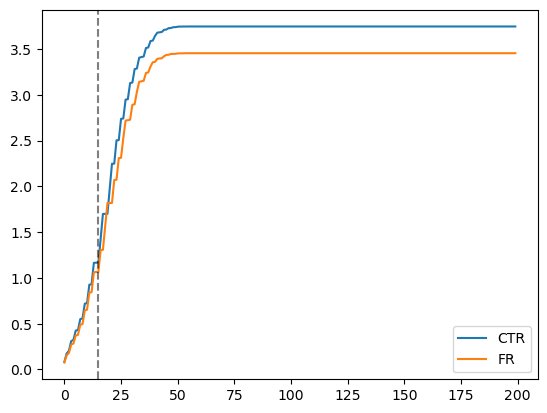

In [44]:
N = 200
cann_width = 0.01
f = 0.1
width_input = f*N//2
AMP = 0.03

C_FR = 0.8
TEMP = 0.05

sig_theta =0.03
averaging = 500
blocksize = 100


fr, ctr = compare_ctr_fr_quadratic_L_sharedbasis(
        N=N, W=make_ring_plus_disorder_J(N=N,threshold_active_fraction=cann_width,g_disorder=0), T=TEMP,
        f_ctr=f, c_ctr=1.0,
        f_fr=f,  c_fr=C_FR,
        width=width_input, amp=AMP, device="cpu",
        sig_theta=sig_theta,
        L=averaging,
        tau_theta_trials=blocksize,
        dtheta=4,
        use_linear_response_dmu=True,
    )
k_top = 15
plt.plot(np.cumsum(ctr[:]), label="CTR")
plt.plot(np.cumsum(fr[:]), label="FR")
plt.axvline(x = k_top,color = 'k', linestyle = '--', alpha =0.5)
plt.legend()
ratio_topk_shared = float((fr[:k_top] / (ctr[:k_top] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in top {k_top} modes (FR/CTR): {ratio_topk_shared:.3f}")
ratio_bottomN_K = float((fr[-k_top:] / (ctr[-k_top:] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in bottom {k_top} modes (FR/CTR): {ratio_bottomN_K:.3f}")

small logged
small logged
small logged
small logged
large logged


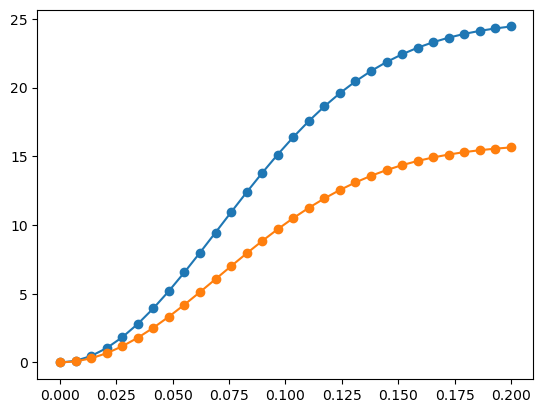

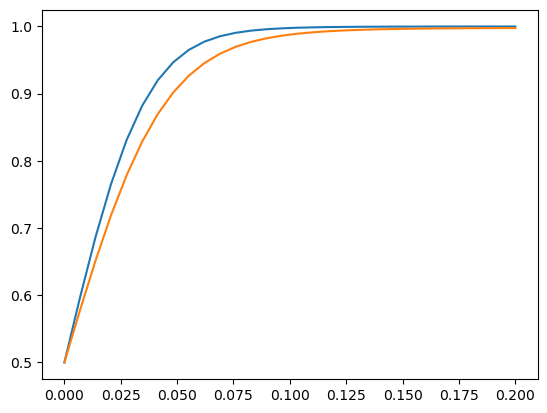

In [45]:
from scipy.stats import norm 
snr_ctr_dtheta = []
snr_fr_dtheta = []
dtheta_vals = np.linspace(0,0.2,30)

N = 200
cann_width = 0.03
TEMP = 0.08
f = 0.1
width_input = f*N//2
AMP = 0.03

C_FR = 0.4

sig_theta =0.06
averaging = 500
blocksize = 100



for dtheta in dtheta_vals:
    fr, ctr = compare_ctr_fr_quadratic_L_sharedbasis(
        N=N, W=make_ring_plus_disorder_J(N=N,threshold_active_fraction=cann_width,g_disorder=0), T=TEMP,
        f_ctr=f, c_ctr=1.0,
        f_fr=f,  c_fr=C_FR,
        width=width_input, amp=AMP, device="cpu",
        sig_theta=sig_theta,
        L=averaging,
        tau_theta_trials=blocksize,
        dtheta=dtheta*N,
        use_linear_response_dmu=True,
    )
    if np.isclose(dtheta,0.025,0.05):
        print('small logged')
        snr_ctr_small = ctr
        snr_fr_small = fr
    if np.isclose(dtheta, 0.15, 0.02):
        print('large logged')
        snr_ctr_large = ctr
        snr_fr_large = fr

    snr_ctr_dtheta.append(ctr.sum())
    snr_fr_dtheta.append(fr.sum())

plt.plot(dtheta_vals,snr_ctr_dtheta, 'o-')
plt.plot(dtheta_vals,snr_fr_dtheta,'o-')
plt.show()

def snr_to_accuracy(snrval):
    dprime = np.sqrt(snrval)
    z = dprime / np.sqrt(2)
    perf = norm.cdf(z)
    return perf
plt.plot(dtheta_vals,snr_to_accuracy(snr_ctr_dtheta))
plt.plot(dtheta_vals,snr_to_accuracy(snr_fr_dtheta))





Ratio of mean SNR in top 15 modes (FR/CTR): 15190.346
Ratio of mean SNR in bottom 15 modes (FR/CTR): 5.030


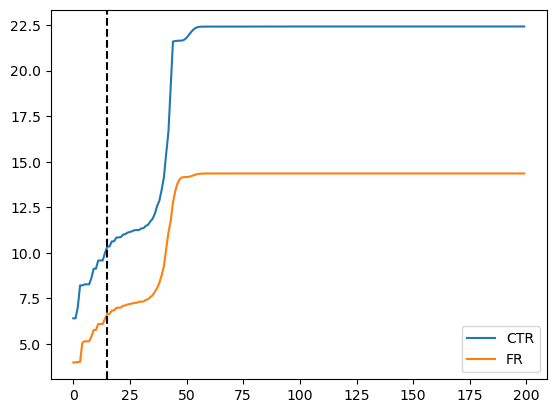

In [46]:
k_top = 15
plt.plot(np.cumsum(snr_ctr_large[:]), label="CTR")
plt.plot(np.cumsum(snr_fr_large[:]), label="FR")
plt.axvline(x = k_top,color = 'k', linestyle = '--')
plt.legend()
ratio_topk_shared = float((snr_fr_large[:k_top] / (snr_ctr_large[:k_top] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in top {k_top} modes (FR/CTR): {ratio_topk_shared:.3f}")
ratio_bottomN_K = float((snr_fr_large[-k_top:] / (snr_ctr_large[-k_top:] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in bottom {k_top} modes (FR/CTR): {ratio_bottomN_K:.3f}")

Ratio of mean SNR in top 15 modes (FR/CTR): 3.691
Ratio of mean SNR in bottom 15 modes (FR/CTR): 0.250


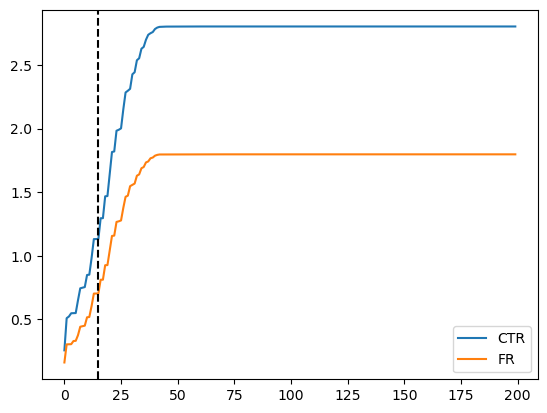

In [47]:
k_top = 15
plt.plot(np.cumsum(snr_ctr_small), label="CTR")
plt.plot(np.cumsum(snr_fr_small), label="FR")
plt.axvline(x = k_top,color = 'k', linestyle = '--')
plt.legend()
ratio_topk_shared = float((snr_fr_small[:k_top] / (snr_ctr_small[:k_top] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in top {k_top} modes (FR/CTR): {ratio_topk_shared:.3f}")
ratio_bottomN_K = float((snr_fr_small[-k_top:] / (snr_ctr_small[-k_top:] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in bottom {k_top} modes (FR/CTR): {ratio_bottomN_K:.3f}")

In [ ]:
@torch.no_grad()
def compare_ctr_fr_dmu(
    N, W, T,
    f_ctr, c_ctr,
    f_fr,  c_fr,
    width, amp, device,
    k_align: int = 10,
    eps: float = 1e-8,
):
    # stimuli
    b1 = ring_gaussian_bump(N, center=100.0, width=width, amp=amp, device=device)
    b2 = ring_gaussian_bump(N, center=105.0, width=width, amp=amp, device=device)

    # MF means
    mu1c, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_ctr, c=c_ctr)
    mu2c, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_ctr, c=c_ctr)
    dmu_c = mu1c - mu2c

    mu1f, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_fr, c=c_fr)
    mu2f, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_fr, c=c_fr)
    dmu_f = mu1f - mu2f

    # slopes
    s_ctr = (mu1c)*(1-mu1c)/T
    s_fr  = (mu1f)*(1-mu1f)/T

    # Σ_eq + counterfactuals
    Sig_ctr    = Sigma_eq_from_s(W, s_ctr, T, c_ctr, eps=eps)
    Sig_fr     = Sigma_eq_from_s(W, s_fr,  T, c_fr,  eps=eps)

    return dict(
        Dmean_ctr=float(s_ctr.mean().item()),
        Dmean_fr=float(s_fr.mean().item()),
        lam_ctr=lam_c, lam_fr=lam_f,
        trSigma_eq_ctr=tr_eq_c,
        trSigma_eq_fr=tr_eq_f,
        align_eq_top10_ctr=topk_alignment(Sig_ctr, dmu_c, k=k_align),
        align_eq_top10_fr=topk_alignment(Sig_fr, dmu_f, k=k_align),
        pr_eq_ctr=pr_ctr,
        pr_eq_fr=pr_fr,
    )

Seed scan:   0%|          | 0/7 [00:00<?, ?it/s]


Summary
ref_center=100
chosen seps=[1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 30, 40, 50, 60, 80, 100]
raw successful runs=35
kept sep bins (n_seeds>=7)=5

First bins:
{'sep': 40, 'delta_deg': 72.0, 'n_seeds': 7, 'mean_dmu_ctr': 0.006999, 'mean_dmu_fr': 0.008607, 'mean_ratio': 0.81316}
{'sep': 50, 'delta_deg': 90.0, 'n_seeds': 7, 'mean_dmu_ctr': 0.006999, 'mean_dmu_fr': 0.008607, 'mean_ratio': 0.813161}
{'sep': 60, 'delta_deg': 108.0, 'n_seeds': 7, 'mean_dmu_ctr': 0.006999, 'mean_dmu_fr': 0.008607, 'mean_ratio': 0.813149}
{'sep': 80, 'delta_deg': 144.0, 'n_seeds': 7, 'mean_dmu_ctr': 0.006999, 'mean_dmu_fr': 0.008607, 'mean_ratio': 0.813155}
{'sep': 100, 'delta_deg': 180.0, 'n_seeds': 7, 'mean_dmu_ctr': 0.006999, 'mean_dmu_fr': 0.008607, 'mean_ratio': 0.813151}


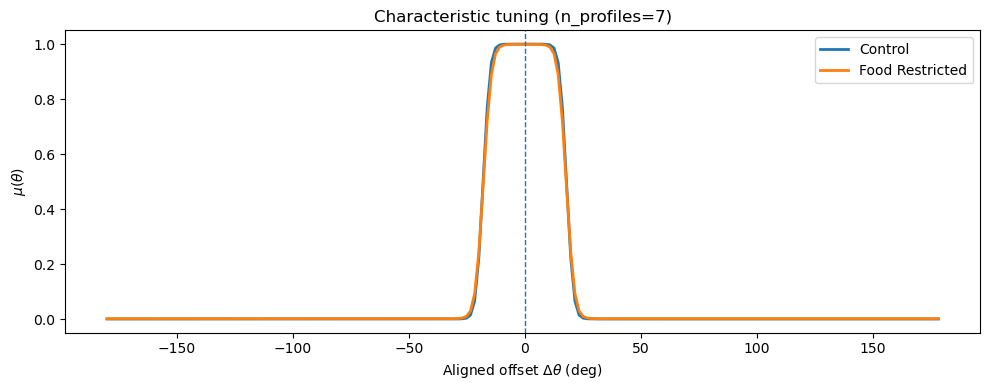

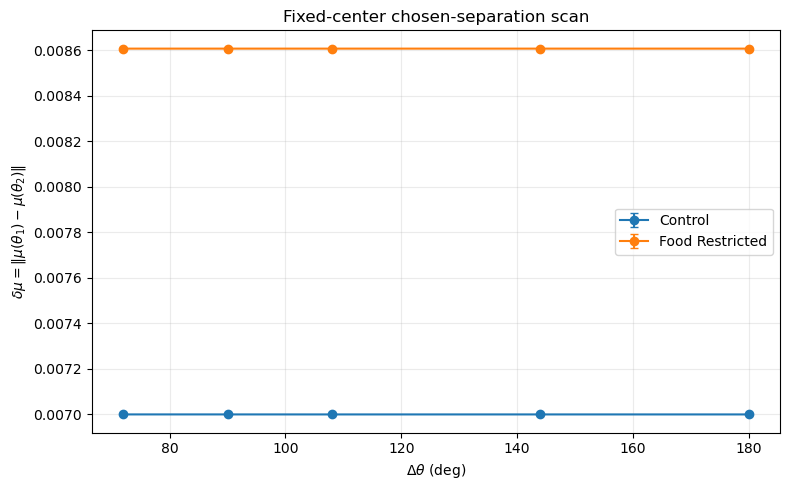

In [34]:
# Fixed-center scan with CHOSEN separation list (fast)
# Requires: make_W, bump, mf_pair_better, mf_solve_convergent, A1

import os
import math
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


CFG = dict(
    # model
    N=200,
    thr_frac=0.05,####
    f_fr=0.1,
    f_ctr=0.1,
    width=N*thr_frac/2,
    amp=0.01, ###
    g_dis=0.0, 
    T=0.03,######
    c_ctr=1.0,
    c_fr=0.64 * 1.27,
    min_A1=0.0,

    # disorder
    seeds=list(range(7)),
    min_kept_seeds=None,       # None => require all seeds

    # fixed center + chosen separations
    ref_center=None,           # None => N//2
    sep_list=[1,2,3,4,6,8,10,12,16,20,24,30,40,50,60,80,100],
    include_zero_sep=False,    # adds sep=0 if True

    # solver
    solver_kw=dict(max_iter=400, tol=1e-6, damping=0.3, bisect_steps=40),

    # compute
    use_process_pool=True,
    max_workers=max(1, (os.cpu_count() or 2) - 1),
)

# ---------- bumpiness metric ----------
def A1(mu: torch.Tensor) -> float:
    mu = mu.clamp_min(0.0)
    N = mu.numel()
    s = float(mu.sum().item())
    if s <= 1e-12:
        return 0.0
    theta = 2 * math.pi * torch.arange(N, device=mu.device).float() / N
    z = (mu * torch.exp(1j * theta)).sum() / s
    return float(torch.abs(z).item())

def make_W(N, thr_frac, g_dis, seed):
    torch.manual_seed(seed)
    idx = torch.arange(N)
    diff = (idx[:, None] - idx[None, :]).abs()
    diff = torch.minimum(diff, N - diff)

    thr = thr_frac * N / 2.0
    K = (diff <= thr).float() / N
    K.fill_diagonal_(0.0)

    R = torch.randn((N, N))
    R = torch.triu(R, diagonal=1)
    R = R + R.T
    R.fill_diagonal_(0.0)

    J_dis = (g_dis / math.sqrt(2.0 * N)) * R
    W = K + J_dis
    W.fill_diagonal_(0.0)
    return 10*W

def bump(N, center, width, amp):
    idx = torch.arange(N).float()
    d = (idx - center).abs()
    d = torch.minimum(d, N - d)
    return amp * torch.exp(-0.5 * (d / width) ** 2)

# ---------- one MF fixed-point solve (convergent or None) ----------
@torch.no_grad()
def mf_solve_convergent(
    W: torch.Tensor,
    b: torch.Tensor,
    T: float,
    f: float,
    c: float,
    init_rho: torch.Tensor | None = None,
    max_iter: int = 400,
    tol: float = 1e-6,
    damping: float = 0.3,
    bisect_steps: int = 40,
) -> tuple[torch.Tensor | None, dict]:
    """
    Solves rho = sigmoid((c*(W@rho + b) - eta)/T) with eta chosen so mean(rho)=f.
    IMPORTANT: uses your field definition x = c*(W@rho + b).

    Returns:
      (rho, info) if converged else (None, info)
    """
    N = W.shape[0]
    device = W.device
    b = b.to(device)

    if init_rho is None:
        rho = torch.full((N,), float(f), device=device)
    else:
        rho = init_rho.to(device).clamp(1e-6, 1 - 1e-6)

    converged = False
    for it in range(max_iter):
        # your field:
        x = c * (W @ rho + b)

        # bisection on eta so mean(sigmoid((x-eta)/T))=f
        eta_lo = (x.min() - 20.0 * T).item()
        eta_hi = (x.max() + 20.0 * T).item()

        def mean_rho(eta: float) -> float:
            return torch.sigmoid((x - eta) / T).mean().item()

        for _ in range(bisect_steps):
            eta_mid = 0.5 * (eta_lo + eta_hi)
            if mean_rho(eta_mid) > f:
                eta_lo = eta_mid
            else:
                eta_hi = eta_mid
        eta = 0.5 * (eta_lo + eta_hi)

        rho_new = torch.sigmoid((x - eta) / T)
        rho_next = (1.0 - damping) * rho + damping * rho_new

        maxdiff = float((rho_next - rho).abs().max().item())
        rho = rho_next

        if maxdiff < tol:
            converged = True
            break

    info = {
        "converged": converged,
        "iters": it + 1,
        "maxdiff": maxdiff,
    }
    return (rho if converged else None), info

def _mean_std(vals):
    arr = np.asarray(vals, dtype=float)
    if arr.size == 0:
        return float("nan"), float("nan")
    m = float(arr.mean())
    s = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    return m, s


def _normalize_seps(cfg):
    N = cfg["N"]
    max_sep = N // 2
    seps = sorted(set(int(s) for s in cfg["sep_list"]))
    if cfg["include_zero_sep"]:
        seps = sorted(set([0] + seps))
    seps = [s for s in seps if 0 <= s <= max_sep]
    if not cfg["include_zero_sep"]:
        seps = [s for s in seps if s > 0]
    if len(seps) == 0:
        raise ValueError("sep_list produced no valid separations.")
    return seps

# ---------- convenient: solve the two-stimulus pair ----------
@torch.no_grad()
def mf_pair_better(
    W: torch.Tensor,
    b1: torch.Tensor,
    b2: torch.Tensor,
    T: float,
    f: float,
    c: float,
    **kw
) -> tuple[torch.Tensor | None, torch.Tensor | None, dict]:
    """
    Returns mu1, mu2 and info. Uses multistart for mu1, then warm-starts mu2 from mu1
    (so both stimuli stay in the same basin).
    """
    mu1, info1 = mf_solve_convergent(W, b1, T, f, c, **{k: kw[k] for k in kw if k in ["max_iter", "tol", "damping", "bisect_steps"]})
    if mu1 is None:
        return None, None, {"ok": False, "stage": "mu1", **info1}

    mu2, info2 = mf_solve_convergent(W, b2, T, f, c, init_rho=mu1, **{k: kw[k] for k in kw if k in ["max_iter", "tol", "damping", "bisect_steps"]})
    if mu2 is None:
        return mu1, None, {"ok": False, "stage": "mu2", "mu1": info1, "mu2": info2}

    return mu1, mu2, {"ok": True, "mu1": info1, "mu2": info2}


def _seed_worker(args):
    torch.set_num_threads(1)
    (
        seed, seps, ref_center,
        N, thr_frac, g_dis, T, f_fr,f_ctr, width, amp, c_ctr, c_fr, min_A1, solver_kw
    ) = args

    W = make_W(N, thr_frac, g_dis, seed)
    b1 = bump(N, ref_center, width, amp)

    # one tuning profile per seed
    tuning_ctr = None
    tuning_fr = None
    mu_ctr_single, _ = mf_solve_convergent(W, b1, T, f_ctr, c_ctr, **solver_kw)
    if mu_ctr_single is not None:
        mu_fr_single, _ = mf_solve_convergent(
            W, b1, T, f_fr, c_fr, init_rho=mu_ctr_single, **solver_kw
        )
        if mu_fr_single is not None and min(A1(mu_ctr_single), A1(mu_fr_single)) >= min_A1:
            shift = (N // 2) - ref_center
            tuning_ctr = torch.roll(mu_ctr_single, shifts=shift).cpu().numpy().tolist()
            tuning_fr = torch.roll(mu_fr_single, shifts=shift).cpu().numpy().tolist()

    rows = []
    for sep in seps:
        c2 = (ref_center + sep) % N
        b2 = bump(N, c2, width, amp)

        mu1c, mu2c, _ = mf_pair_better(W, b1, b2, T, f_ctr, c_ctr, **solver_kw)
        if mu1c is None or mu2c is None:
            continue

        mu1f, mu2f, _ = mf_pair_better(W, b1, b2, T, f_fr, c_fr, **solver_kw)
        if mu1f is None or mu2f is None:
            continue

        a1_min = min(A1(mu1c), A1(mu2c), A1(mu1f), A1(mu2f))
        if a1_min < min_A1:
            continue

        dmu_ctr = float(torch.linalg.norm(mu1c - mu2c).item())
        dmu_fr = float(torch.linalg.norm(mu1f - mu2f).item())

        rows.append(dict(
            seed=int(seed),
            sep=int(sep),
            delta_theta_deg=float(360.0 * sep / N),
            dmu_ctr=dmu_ctr,
            dmu_fr=dmu_fr,
            ratio=dmu_ctr / (dmu_fr + 1e-12),
            a1_min=float(a1_min),
        ))

    return rows, tuning_ctr, tuning_fr


def run_fixed_center_scan(cfg):
    N = cfg["N"]
    ref_center = N // 2 if cfg["ref_center"] is None else int(cfg["ref_center"])
    seps = _normalize_seps(cfg)
    min_kept = len(cfg["seeds"]) if cfg["min_kept_seeds"] is None else int(cfg["min_kept_seeds"])

    jobs = [
        (
            seed, seps, ref_center,
            cfg["N"], cfg["thr_frac"], cfg["g_dis"], cfg["T"], cfg["f_fr"], cfg["f_ctr"],
            cfg["width"], cfg["amp"], cfg["c_ctr"], cfg["c_fr"], cfg["min_A1"],
            cfg["solver_kw"]
        )
        for seed in cfg["seeds"]
    ]

    raw_pairs = []
    t_ctr, t_fr = [], []

    if cfg["use_process_pool"] and cfg["max_workers"] > 1:
        with ProcessPoolExecutor(max_workers=cfg["max_workers"]) as ex:
            futs = [ex.submit(_seed_worker, j) for j in jobs]
            for fut in tqdm(as_completed(futs), total=len(futs), desc="Seed scan"):
                rows, tc, tf = fut.result()
                raw_pairs.extend(rows)
                if tc is not None and tf is not None:
                    t_ctr.append(tc)
                    t_fr.append(tf)
    else:
        for j in tqdm(jobs, desc="Seed scan"):
            rows, tc, tf = _seed_worker(j)
            raw_pairs.extend(rows)
            if tc is not None and tf is not None:
                t_ctr.append(tc)
                t_fr.append(tf)

    # aggregate by sep
    grouped = {}
    for r in raw_pairs:
        k = r["sep"]
        if k not in grouped:
            grouped[k] = dict(sep=k, deg=r["delta_theta_deg"], seeds=[], ctr=[], fr=[], ratio=[], a1=[])
        grouped[k]["seeds"].append(r["seed"])
        grouped[k]["ctr"].append(r["dmu_ctr"])
        grouped[k]["fr"].append(r["dmu_fr"])
        grouped[k]["ratio"].append(r["ratio"])
        grouped[k]["a1"].append(r["a1_min"])

    sep_results = []
    for g in grouped.values():
        if len(g["seeds"]) < min_kept:
            continue
        m_ctr, s_ctr = _mean_std(g["ctr"])
        m_fr, s_fr = _mean_std(g["fr"])
        m_ratio, s_ratio = _mean_std(g["ratio"])
        m_a1, _ = _mean_std(g["a1"])
        sep_results.append(dict(
            sep=g["sep"], delta_theta_deg=g["deg"], n_seeds=len(g["seeds"]),
            mean_dmu_ctr=m_ctr, std_dmu_ctr=s_ctr,
            mean_dmu_fr=m_fr, std_dmu_fr=s_fr,
            mean_ratio=m_ratio, std_ratio=s_ratio,
            mean_a1_min=m_a1
        ))
    sep_results.sort(key=lambda x: x["sep"])

    tuning = None
    if len(t_ctr) > 0:
        ctr = np.asarray(t_ctr, float)
        fr = np.asarray(t_fr, float)
        theta_deg = (np.arange(N) - (N // 2)) * (360.0 / N)
        tuning = dict(
            theta_deg=theta_deg,
            mean_ctr=ctr.mean(axis=0),
            std_ctr=ctr.std(axis=0, ddof=1) if ctr.shape[0] > 1 else np.zeros(N),
            mean_fr=fr.mean(axis=0),
            std_fr=fr.std(axis=0, ddof=1) if fr.shape[0] > 1 else np.zeros(N),
            n_profiles=int(ctr.shape[0])
        )

    return raw_pairs, sep_results, tuning, seps, ref_center, min_kept


def plot_delta_mu_vs_delta_theta(sep_results):
    x = np.array([r["delta_theta_deg"] for r in sep_results], float)
    y1 = np.array([r["mean_dmu_ctr"] for r in sep_results], float)
    e1 = np.array([r["std_dmu_ctr"] for r in sep_results], float)
    y2 = np.array([r["mean_dmu_fr"] for r in sep_results], float)
    e2 = np.array([r["std_dmu_fr"] for r in sep_results], float)

    plt.figure(figsize=(8,5))
    plt.errorbar(x, y1, yerr=e1, fmt="o-", capsize=3, label="Control")
    plt.errorbar(x, y2, yerr=e2, fmt="o-", capsize=3, label="Food Restricted")
    plt.xlabel(r"$\Delta\theta$ (deg)")
    plt.ylabel(r"$\delta\mu=\|\mu(\theta_1)-\mu(\theta_2)\|$")
    plt.title(r"Fixed-center chosen-separation scan")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_characteristic_tuning(tuning):
    if tuning is None:
        print("No valid tuning profiles survived filters.")
        return
    x = tuning["theta_deg"]
    plt.figure(figsize=(10,4))
    plt.plot(x, tuning["mean_ctr"], lw=2, label="Control")
    plt.fill_between(x, tuning["mean_ctr"]-tuning["std_ctr"], tuning["mean_ctr"]+tuning["std_ctr"], alpha=0.2)
    plt.plot(x, tuning["mean_fr"], lw=2, label="Food Restricted")
    plt.fill_between(x, tuning["mean_fr"]-tuning["std_fr"], tuning["mean_fr"]+tuning["std_fr"], alpha=0.2)
    plt.axvline(0, ls="--", lw=1)
    plt.xlabel(r"Aligned offset $\Delta\theta$ (deg)")
    plt.ylabel(r"$\mu(\theta)$")
    plt.title(f"Characteristic tuning (n_profiles={tuning['n_profiles']})")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Run
RAW_PAIRS, SEP_RESULTS, TUNING, SEPS, REF_CENTER, MIN_KEPT = run_fixed_center_scan(CFG)

print("\nSummary")
print(f"ref_center={REF_CENTER}")
print(f"chosen seps={SEPS}")
print(f"raw successful runs={len(RAW_PAIRS)}")
print(f"kept sep bins (n_seeds>={MIN_KEPT})={len(SEP_RESULTS)}")
print("\nFirst bins:")
for r in SEP_RESULTS[:10]:
    print(dict(
        sep=r["sep"],
        delta_deg=round(r["delta_theta_deg"], 3),
        n_seeds=r["n_seeds"],
        mean_dmu_ctr=round(r["mean_dmu_ctr"], 6),
        mean_dmu_fr=round(r["mean_dmu_fr"], 6),
        mean_ratio=round(r["mean_ratio"], 6),
    ))

plot_characteristic_tuning(TUNING)
plot_delta_mu_vs_delta_theta(SEP_RESULTS)


In [34]:
def compare_ctr_fr_evals(
    N, W, T,
    f_ctr, c_ctr,
    f_fr,  c_fr,
    width, amp, dtheta,device,
    eps: float = 1e-8,
):
    A = torch.randn(N, N, device=device)
    Q, _ = torch.linalg.qr(A)
    W =  Q @ W @ Q.T

    # stimuli
    b1 = ring_gaussian_bump(N, center=N//2, width=width, amp=amp, device=device)
    b2 = ring_gaussian_bump(N, center=(N//2+dtheta), width=width, amp=amp, device=device)

    # b1 = Q @ b1
    # b2 = Q @ b2

    dx = (b1-b2)
    # MF means
    mu1c, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_ctr, c=c_ctr)
    mu2c, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_ctr, c=c_ctr)
    
 

    mu1f, _ = solve_mean_field_fixed_activity(W, b1, T=T, f=f_fr, c=c_fr)
    mu2f, _ = solve_mean_field_fixed_activity(W, b2, T=T, f=f_fr, c=c_fr)
    
    # gain margin
    lam_c = lam_max_effective(W, mu1c, T=T, c=c_ctr)
    lam_f = lam_max_effective(W, mu1f, T=T, c=c_fr)
    if lam_c > 0.96 or lam_f > 0.96:
        print('extreme lambda')
        return float('nan')
    # print(f"lam_max: ctr,fr={lam_c:.3f},{lam_f:.3f}")


    # slopes
    s_ctr = (mu1c)*(1-mu1c)/T
    s_fr  = (mu1f)*(1-mu1f)/T

    # Gamma matrices and evals
    Gamma_ctr    = Chi_eq_from_s(W, s_ctr, T, c_ctr, eps=eps)
    Gamma_fr     = Chi_eq_from_s(W, s_fr,  T, c_fr,  eps=eps)
    

    try:
        evals_ctr,evecs_ctr = torch.linalg.eigh(Gamma_ctr)
    except:
        print('ctr eigh failed')
        return float('nan')
    try:
        evals_fr,evecs_fr = torch.linalg.eigh(Gamma_fr)
    except:
        print('fr eigh failed')
        return float('nan')

    # Output change to mean Evalue
    # print(f"Mean Gamma Eval ctr,fr={evals_ctr.mean().item():.3f},{evals_fr.mean().item():.3f}")

    # Participation ratio of evals of Sigma
    # pr_ctr = float((evals_ctr.sum() ** 2 / (evals_ctr ** 2).sum()).item())
    # pr_fr = float((evals_fr.sum() ** 2 / (evals_fr ** 2).sum()).item())

    # print(f"Pr Gamma Eval: ctr,fr={pr_ctr:.2f},{pr_fr:.2f}")


    # signal_eigenvalue_phase(Gamma_ctr, dx)
    # signal_eigenvalue_phase(Gamma_fr,dx)
    # plt.plot((c_ctr*evals_ctr.cpu()),(c_fr*evals_fr.cpu()), "o")
    # plt.plot([evals_ctr.min().item(), evals_ctr.max().item()], [evals_ctr.min().item(), evals_ctr.max().item()], "k--")
    # plt.xlabel("C*CTR eigenvalues")
    # plt.ylabel("C*FR eigenvalues")
    # plt.show()
    # plt.plot((c_ctr*evals_ctr.cpu())**2,(c_fr*evals_fr.cpu())**2, "o")
    # plt.plot([evals_ctr.min().item()**2, evals_ctr.max().item()**2], [evals_ctr.min().item()**2, evals_ctr.max().item()**2], "k--")
    # plt.xlabel("(C*CTR eigenvalues)^2")
    # plt.ylabel("(C*FR eigenvalues)^2")
    # plt.show()



    # O = torch.abs(evecs_ctr.T @ evecs_fr)
    # plt.imshow(O.cpu(), aspect='auto')
    # plt.colorbar()
    # plt.title("Eigenvector overlap")
    # plt.show()
    # diag_overlap = torch.abs(torch.sum(evecs_ctr * evecs_fr, dim=0))
    # print("Mean eigenvector overlap:", diag_overlap.mean().item())



    dmu_c = mu1c - mu2c
    dmu_norm_c = dmu_c.norm().item()
    dmu_f = mu1f -   mu2f
    dmu_norm_f = dmu_f.norm().item()
    dmu_norm2_est_fr = float((c_fr*Gamma_fr @ dx).norm().item())
    dmu_norm2_est_ctr = float((c_ctr*Gamma_ctr @ dx).norm().item())


    # print(f"(c * zfr/z_ctr) = {(c_fr*(evals_fr).sum().item()/(c_ctr*(evals_ctr).sum().item())):.3f}")

    # print(f"(c * zfr/z_ctr)**2 = {(c_fr**2*(evals_fr**2).sum().item()/(c_ctr**2*(evals_ctr**2).sum().item())):.3f}")

    # print(f"Ratio Actual Dmu norms (FR/CTR) = {dmu_norm_f/dmu_norm_c:.3f}")
    # print(f"Ratio LR Dmu norms (FR/CTR) = {dmu_norm2_est_fr/dmu_norm2_est_ctr:.3f}")
    print(f"||Δμ||_2 estimate CTR|| LR {dmu_norm2_est_ctr:.2f},act {dmu_norm_c:.2f} | "
          f"FR|| LR {dmu_norm2_est_fr:.2f},act {dmu_norm_f:.2f}")
    if not np.isclose(dmu_norm2_est_ctr,dmu_norm_c, atol=0.10):
        print('mismatch LR')
        return float('nan')
    if not np.isclose(dmu_norm2_est_fr,dmu_norm_f, atol=0.10):
        print('mismatch LR')
        return float('nan')
    # random projection
    # dx = torch.randn(N, device=device)

    proj_ctr = (evecs_ctr @ dx) ** 2
    proj_fr  = (evecs_fr @ dx) ** 2

    signal_ctr = torch.sum((evals_ctr ** 2) * proj_ctr)
    signal_fr  = torch.sum((evals_fr ** 2) * proj_fr)
    true_signal_ratio = torch.sqrt((c_fr**2 * signal_fr) / (c_ctr**2 * signal_ctr)).item()
    # print("True signal ratio =", torch.sqrt((c_fr**2 * signal_fr) / (c_ctr**2 * signal_ctr)).item())
    
    return true_signal_ratio



N = 300
dtheta = 5
device = "cpu"



thr_frac = 0.1
f = 0.1
width = thr_frac*N//2
wrec = 1
amp =0.03
Temps = [0.05]

W = wrec*make_ring_plus_disorder_J(N, thr_frac, g_disorder=0.00, device=device, seed=0)

for c_ctr in [5]:
    print("*"*30)
    print(f"c_ctr = {c_ctr}")
    c_fr = c_ctr*0.64*1.27

    signal_ratio = compare_ctr_fr_evals(
                            N=N, W=W, T=Temps[0],
                            f_ctr=f, c_ctr=c_ctr,
                            f_fr=f,  c_fr=c_fr,
                            width=width, amp=amp,dtheta = dtheta, device=device
                            )
    print(f"Signal ratio (FR/CTR) = {signal_ratio:.3f}")

******************************
c_ctr = 5
||Δμ||_2 estimate CTR|| LR 0.74,act 0.72 | FR|| LR 0.55,act 0.55
Signal ratio (FR/CTR) = 0.753


In [35]:
import optuna
import numpy as np
import pandas as pd

target = 1.15

def objective(trial):

    f = trial.suggest_float("f", 0.05, 0.4)
    thr_frac = trial.suggest_float("thr_frac", 0.01, 0.4)
    width = trial.suggest_int("width", 1, N//2)
    wrec = trial.suggest_float("wrec", 0.1,50.0)
    amp = trial.suggest_float("amp", 0.001, 1.0)
    temp = trial.suggest_float("temp", 0.001, 0.1)
    c_ctr = trial.suggest_float("c_ctr", 0.1, 50.0)

    c_fr = c_ctr * 0.64 * 1.27

    W = wrec * make_ring_plus_disorder_J(
        N,
        thr_frac,
        g_disorder=0.0,
        device=device,
        seed=0
    )

    signal_ratio = compare_ctr_fr_evals(
        N=N,
        W=W,
        T=temp,
        f_ctr=f,
        c_ctr=c_ctr,
        f_fr=f,
        c_fr=c_fr,
        width=width,
        amp=amp,
        dtheta=dtheta,
        device=device
    )

    trial.set_user_attr("signal_ratio", signal_ratio)

    score = -abs(signal_ratio - target)

    return score


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=100, n_jobs=-1)

[I 2026-03-09 14:01:48,529] A new study created in memory with name: no-name-c2c852a4-5fd8-422d-9b12-e87e22b5a558


||Δμ||_2 estimate CTR|| LR 1.44,act 1.37 | FR|| LR 1.28,act 1.23


[I 2026-03-09 14:04:46,028] Trial 26 finished with value: -0.20036246776580802 and parameters: {'f': 0.083563870698496, 'thr_frac': 0.3905908740787337, 'width': 66, 'wrec': 0.17087500483478224, 'amp': 0.777610379714611, 'temp': 0.09814311987301234, 'c_ctr': 9.808712782305715}. Best is trial 26 with value: -0.20036246776580802.
[W 2026-03-09 14:05:18,101] Trial 6 failed with parameters: {'f': 0.10138916749994156, 'thr_frac': 0.2304003737947711, 'width': 1, 'wrec': 38.65776027541706, 'amp': 0.3137750155305298, 'temp': 0.0672969612285756, 'c_ctr': 21.088687089102695} because of the following error: The value nan is not acceptable.
[W 2026-03-09 14:05:18,122] Trial 6 failed with value nan.


extreme lambda
||Δμ||_2 estimate CTR|| LR 0.13,act 3.97 | FR|| LR 0.13,act 3.98
mismatch LR


[W 2026-03-09 14:05:21,458] Trial 15 failed with parameters: {'f': 0.176078763620868, 'thr_frac': 0.04778855329927756, 'width': 28, 'wrec': 25.94813225077841, 'amp': 0.08224855629015664, 'temp': 0.05374052311835232, 'c_ctr': 33.80531994667633} because of the following error: The value nan is not acceptable.
[W 2026-03-09 14:05:21,617] Trial 15 failed with value nan.


...

||Δμ||_2 estimate CTR|| LR 0.20,act 0.19 | FR|| LR 0.20,act 0.16


[W 2026-03-09 14:18:26,549] Trial 90 failed with parameters: {'f': 0.2886341086259877, 'thr_frac': 0.22012536622988715, 'width': 98, 'wrec': 48.19270238793159, 'amp': 0.33536464136093325, 'temp': 0.00131423129136473, 'c_ctr': 32.728626967640814} because of the following error: The value nan is not acceptable.
[W 2026-03-09 14:18:26,549] Trial 90 failed with value nan.


extreme lambda


[W 2026-03-09 14:18:26,895] Trial 93 failed with parameters: {'f': 0.17449079140430054, 'thr_frac': 0.20941263760991927, 'width': 99, 'wrec': 48.8817778416732, 'amp': 0.33592859166128064, 'temp': 0.044622833062135873, 'c_ctr': 33.216311096319835} because of the following error: The value nan is not acceptable.
[W 2026-03-09 14:18:26,897] Trial 93 failed with value nan.
[W 2026-03-09 14:18:26,953] Trial 92 failed with parameters: {'f': 0.29501209004789436, 'thr_frac': 0.2216248261687488, 'width': 99, 'wrec': 47.09775965011137, 'amp': 0.34794434373582295, 'temp': 0.044028796394899844, 'c_ctr': 30.933191227117305} because of the following error: The value nan is not acceptable.
[W 2026-03-09 14:18:26,954] Trial 92 failed with value nan.
[W 2026-03-09 14:18:27,020] Trial 89 failed with parameters: {'f': 0.17392738617310624, 'thr_frac': 0.2149859856366662, 'width': 98, 'wrec': 40.70595365322463, 'amp': 0.3708070837614753, 'temp': 0.003004055516508078, 'c_ctr': 32.5358176169457} because of t

extreme lambda
extreme lambda
||Δμ||_2 estimate CTR|| LR 0.21,act 0.00 | FR|| LR 0.20,act 0.00
mismatch LR


In [36]:
records = []

for t in study.trials:

    if t.state.name != "COMPLETE":
        continue

    row = t.params.copy()
    row["signal_ratio"] = t.user_attrs["signal_ratio"]

    records.append(row)

df = pd.DataFrame(records)

In [37]:
good = df[(df.signal_ratio >= 1.0) & (df.signal_ratio <= 1.3)]

print("Good samples:", len(good))

Good samples: 4


In [38]:
good.describe()

,f,thr_frac,width,wrec,amp,temp,c_ctr,signal_ratio
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,0.354284,0.145146,96.000000,30.612732,0.382876,0.072633,16.385648,1.158153
std,0.040927,0.018176,53.746318,13.996719,0.187887,0.031120,9.130379,0.098888
min,0.306088,0.127998,24.000000,13.946071,0.187191,0.028017,5.064753,1.033928
25%,0.328061,0.130395,72.750000,24.843734,0.310112,0.065543,11.519809,1.122340
50%,0.358179,0.144415,106.000000,30.235860,0.352497,0.081314,17.119991,1.161786
75%,0.384402,0.159166,129.250000,36.004859,0.425261,0.088404,21.985830,1.197599
max,0.394690,0.163756,148.000000,48.033139,0.639318,0.099887,26.237859,1.275112


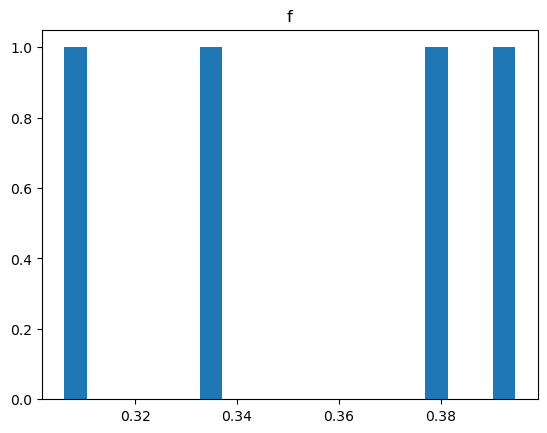

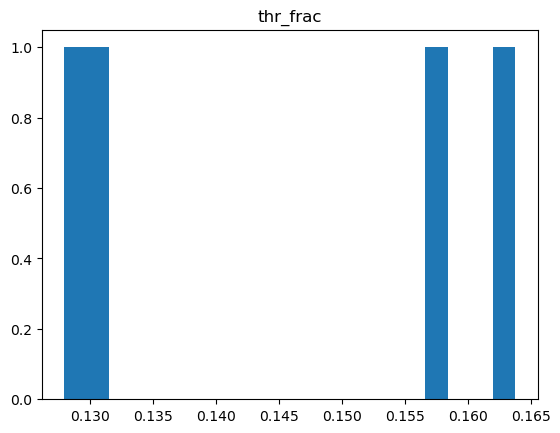

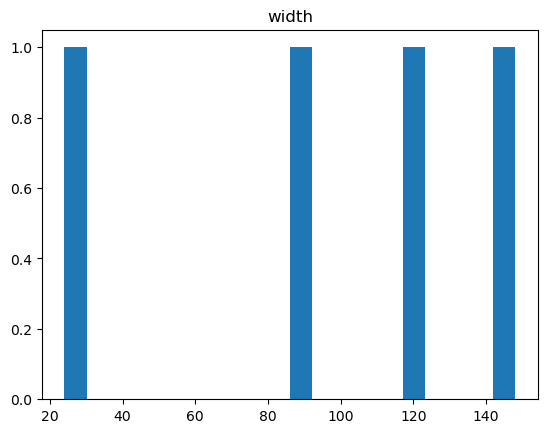

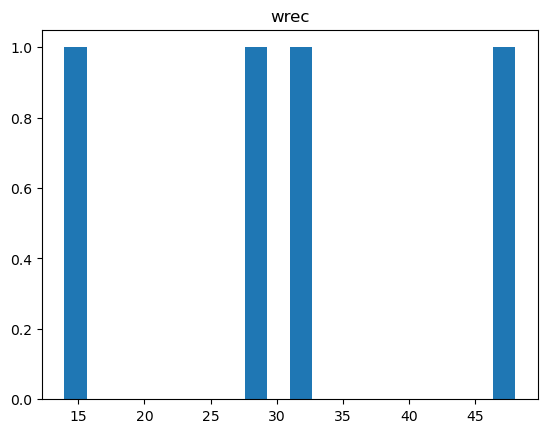

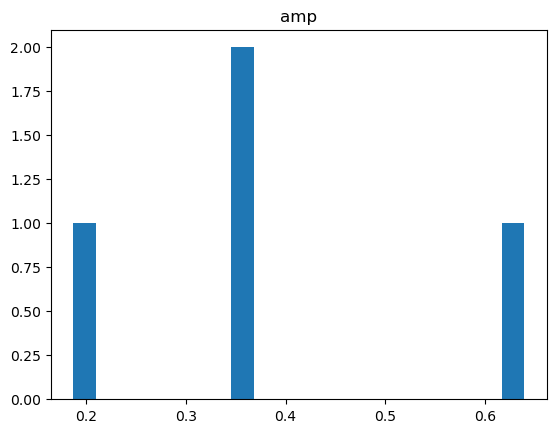

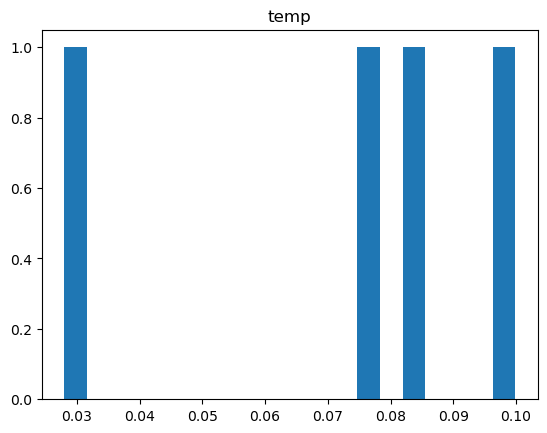

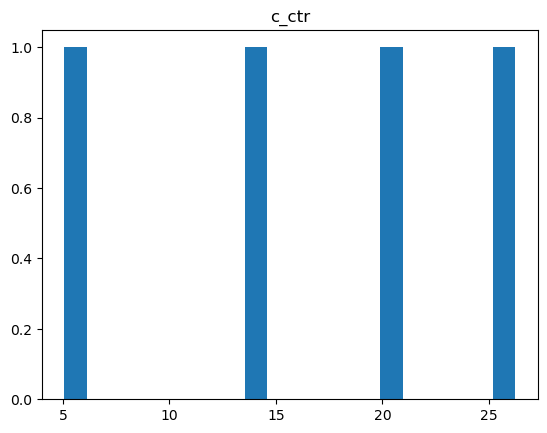

In [39]:
params = ["f","thr_frac","width","wrec","amp","temp","c_ctr"]

for p in params:

    plt.figure()
    plt.hist(good[p], bins=20)
    plt.title(p)
    plt.show()

Mean FR rho: 0.9998038379960635
Mean CTR rho: 0.9999533225076628


Text(0, 0.5, 'C*D_eff FR')

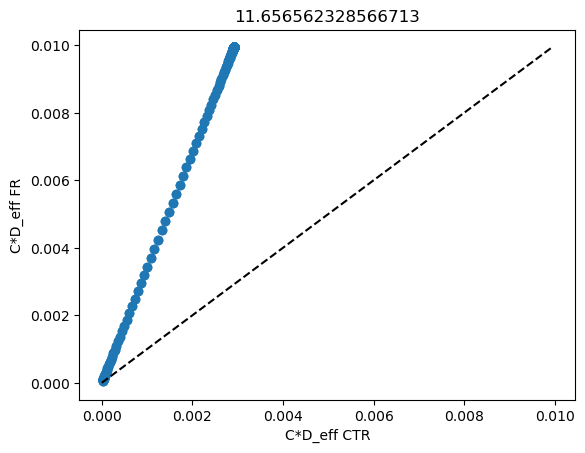

In [98]:
import numpy as np

def sigmoid(x):
    return 1/(1+np.exp(-x))

def gauss_hermite_noisy_sigmoid(u, T, sigma, n=20):
    # E_z[ sigmoid((u + sqrt(2)*sigma*x_k)/T) ]
    x, w = np.polynomial.hermite.hermgauss(n)
    vals = sigmoid((u[..., None] + np.sqrt(2)*sigma[..., None]*x)/T)
    return (w * vals).sum(axis=-1) / np.sqrt(np.pi)

def sigma_vdep(u, sigma0=0.0, sigma1=0.02, u0=0.0, du=0.02):
    return sigma0 + sigma1 * sigmoid((u - u0)/du)

def solve_mf_padamsey(J, b, c, T, f=None, b0=0.0,
                      sigma0=0.0, sigma1=0.02, u0=0.0, du=0.02,
                      max_iter=200, damping=0.3, tol=1e-8):
    N = len(b)
    rho = np.full(N, 0.1)

    eta = 0.0
    for _ in range(max_iter):
        u = c*(J @ rho) + b + b0 - eta
        sig = sigma_vdep(u, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)
        rho_new = gauss_hermite_noisy_sigmoid(u, T, sig)

        # optional homeostasis
        if f is not None:
            eta += 0.5*(rho_new.mean() - f)

        rho_next = (1-damping)*rho + damping*rho_new
        if np.max(np.abs(rho_next - rho)) < tol:
            rho = rho_next
            break
        rho = rho_next

    return rho, eta

def noisy_transfer(u, T, sigma0=0.0, sigma1=0.02, u0=0.0, du=0.02):
    sig = sigma_vdep(u, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)
    return gauss_hermite_noisy_sigmoid(u, T, sig)

def D_eff_from_u(u, T, sigma0=0.0, sigma1=0.02, u0=0.0, du=0.02, eps=1e-5):
    up = noisy_transfer(u + eps, T, sigma0, sigma1, u0, du)
    um = noisy_transfer(u - eps, T, sigma0, sigma1, u0, du)
    return (up - um) / (2*eps)


N=500
thr_frac = 0.1
f = None
amp =0.1
c_ctr = 1.0
c_fr = c_ctr*0.64*1.27
T = 0.02

sigma0_fr = 0.0
sigma1_fr = 0.02
b0_fr = 0.095

sigma0_ctr = 0.0
sigma1_ctr = 0.0
b0_ctr = 0.095

bump = ring_gaussian_bump(N, center=N//2, width=thr_frac*N//2, amp=amp, device="cpu").cpu().numpy()
weight = make_ring_plus_disorder_J(N=N, threshold_active_fraction=thr_frac, g_disorder=0.0, device="cpu", seed=0).cpu().numpy()

fr_rho, fr_eta = solve_mf_padamsey(weight, b=bump, c=c_fr, T=T, f=f,b0=b0_fr, sigma0=sigma0_fr, sigma1=sigma1_fr)
fr_u = c_fr * (weight @ fr_rho) + bump + b0_fr - fr_eta
print("Mean FR rho:", fr_rho.mean())
D_eff_fr = D_eff_from_u(fr_u, T, sigma0=sigma0_fr, sigma1=sigma1_fr)
ctr_rho, ctr_eta = solve_mf_padamsey(weight, b=bump, c=c_ctr, T=T, f=f, b0=b0_ctr, sigma0=sigma0_ctr, sigma1=sigma1_ctr)
ctr_u = c_ctr * (weight @ ctr_rho) + bump + b0_ctr - ctr_eta
print("Mean CTR rho:", ctr_rho.mean())
D_eff_ctr = D_eff_from_u(ctr_u, T, sigma0=sigma0_ctr, sigma1=sigma1_ctr)

plt.plot(c_ctr*D_eff_ctr, c_fr*D_eff_fr, "o")
plt.plot([0, np.max([c_ctr*D_eff_ctr, c_fr*D_eff_fr])], [0, np.max([c_ctr*D_eff_ctr, c_fr*D_eff_fr])], "k--")
plt.title(np.sum((D_eff_fr*c_fr)**2)/np.sum((D_eff_ctr*c_ctr)**2))
plt.xlabel("C*D_eff CTR")
plt.ylabel("C*D_eff FR")


mean rho ctr, fr: 0.1494496461766072 0.1524913806116385
eta ctr, fr: 0.08938969932448697 0.12008567110725414
mean D_eff ctr, fr: 1.5142085608661646 1.913757454115184
max  D_eff ctr, fr: 12.478245018968103 11.917744099360082
criticality proxy lambda_max ctr, fr: 0.48310451676039484 0.5233454352528741
criticality proxy c*lambda_max ctr, fr: 0.48310451676039484 0.4253751697735361
Q_ctr, Q_fr, ratio: 4737.8173707932165 3357.3752581403955 0.7086333210809888


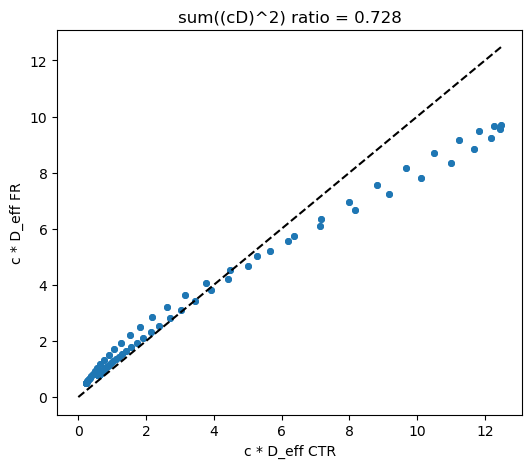

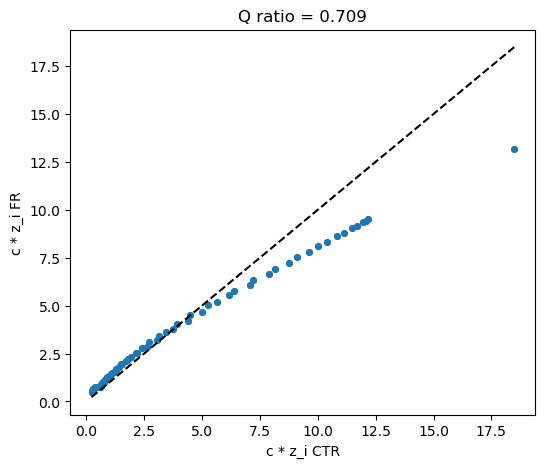

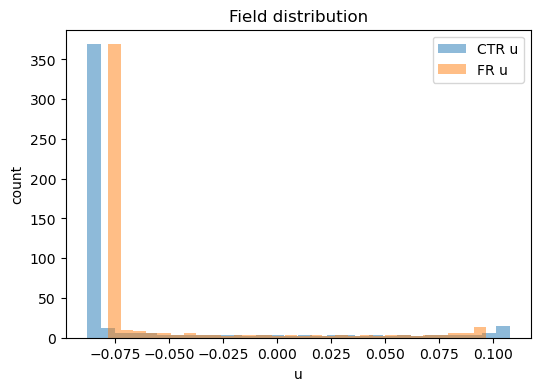

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Basic nonlinearities
# ------------------------------------------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def gauss_hermite_noisy_sigmoid(u, T, sigma, n=30):
    """
    E_z [ sigmoid((u + sqrt(2)*sigma*z)/T) ] using Gauss-Hermite quadrature.
    u, sigma: shape (N,)
    """
    x, w = np.polynomial.hermite.hermgauss(n)
    vals = sigmoid((u[..., None] + np.sqrt(2.0) * sigma[..., None] * x) / T)
    return (vals * w).sum(axis=-1) / np.sqrt(np.pi)

def sigma_vdep(u, sigma0=0.0, sigma1=0.0, u0=0.0, du=0.02):
    """
    Voltage-dependent intrinsic noise.
    If sigma1=0, this reduces to constant sigma0.
    """
    return sigma0 + sigma1 * sigmoid((u - u0) / du)

def noisy_transfer(u, T, sigma0=0.0, sigma1=0.0, u0=0.0, du=0.02):
    sig = sigma_vdep(u, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)
    return gauss_hermite_noisy_sigmoid(u, T, sig)

def D_eff_from_u(u, T, sigma0=0.0, sigma1=0.0, u0=0.0, du=0.02, eps=1e-5):
    """
    Effective slope d rho / d u, computed numerically.
    Important: input is u (field), not rho.
    """
    up = noisy_transfer(u + eps, T, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)
    um = noisy_transfer(u - eps, T, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)
    return (up - um) / (2.0 * eps)

# ------------------------------------------------------------
# Mean-field solve with SHARED / SLOW eta
# eta is adjusted to keep the REFERENCE input at mean f,
# not the actual stimulus on every iteration.
# ------------------------------------------------------------
def solve_mf_shared_eta(
    J, b, b_ref, c, T, f=None,
    b0=0.0,
    sigma0=0.0, sigma1=0.0, u0=0.0, du=0.02,
    max_iter=400, damping=0.3, eta_lr=0.5, tol=1e-8,
    rho_init=None, eta_init=0.0,
):
    """
    Solve rho = F(u), with
        u = c * (J rho) + b + b0 - eta

    eta is updated using a REFERENCE drive b_ref:
        u_ref = c * (J rho) + b_ref + b0 - eta
    and nudged so mean(F(u_ref)) -> f.

    This makes eta condition-level / slow rather than stimulus-specific.
    """
    N = len(b)
    if rho_init is None:
        rho = np.full(N, f if f is not None else 0.1, dtype=float)
    else:
        rho = rho_init.copy().astype(float)

    eta = float(eta_init)

    for _ in range(max_iter):
        recur = J @ rho

        # actual stimulus
        u = c * recur + b + b0 - eta
        rho_new = noisy_transfer(u, T, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)

        # shared / slow homeostasis using reference drive
        if f is not None:
            u_ref = c * recur + b_ref + b0 - eta
            rho_ref = noisy_transfer(u_ref, T, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)
            eta += eta_lr * (rho_ref.mean() - f)

        rho_next = (1.0 - damping) * rho + damping * rho_new

        if np.max(np.abs(rho_next - rho)) < tol:
            rho = rho_next
            break

        rho = rho_next

    # final actual field and slope
    recur = J @ rho
    u = c * recur + b + b0 - eta
    D_eff = D_eff_from_u(u, T, sigma0=sigma0, sigma1=sigma1, u0=u0, du=du)

    return rho, eta, u, D_eff

# ------------------------------------------------------------
# Susceptibility and Q
# ------------------------------------------------------------
def gamma_from_Deff(J, c, D_eff, eps=1e-10):
    """
    Gamma = (D_eff^{-1} - c J)^-1
    """
    H = np.diag(1.0 / (D_eff + eps)) - c * J
    return np.linalg.inv(H)

def Q_from_gamma(Gamma, c):
    """
    Q = sum_i (c z_i)^2 where z_i are eigenvalues of Gamma.
    Assumes Gamma is symmetric or close to symmetric.
    """
    evals = np.linalg.eigvalsh(0.5 * (Gamma + Gamma.T))
    Q = np.sum((c * evals) ** 2)
    return Q, evals

def criticality_proxy(J, c, D_eff):
    """
    Useful diagnostic:
      lambda_max of sqrt(D) J sqrt(D), then alpha* = c * lambda_max
    If alpha* increases, Gamma often gets larger.
    """
    s = np.sqrt(np.maximum(D_eff, 0.0))
    M = (s[:, None] * J) * s[None, :]
    lammax = np.linalg.eigvalsh(0.5 * (M + M.T)).max()
    return lammax, c * lammax

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
if __name__ == "__main__":
    # Your setup
    N = 500
    thr_frac = 0.1
    f = 0.1
    amp = 0.1
    c_ctr = 1.0
    c_fr = 0.64 * 1.27   # ~0.813
    T = 0.02

    # FR knobs
    sigma0_fr = 0.0
    sigma1_fr = 0.02     # try 0 first, then small positive
    b0_fr = 0.04         # try 0 first, then positive

    # CTR knobs
    sigma0_ctr = 0.0
    sigma1_ctr = 0.0
    b0_ctr = 0.0

    # Replace these with your actual functions
    bump = ring_gaussian_bump(
        N, center=N // 2, width=thr_frac * N // 2, amp=amp, device="cpu"
    ).cpu().numpy()

    J = make_ring_plus_disorder_J(
        N=N,
        threshold_active_fraction=thr_frac,
        g_disorder=0.0,
        device="cpu",
        seed=0
    ).cpu().numpy()

    # Reference input for shared eta:
    # On a ring, the ensemble average over all bump positions is uniform.
    b_ref = np.full_like(bump, bump.mean())

    # ---- Solve CTR and FR with shared eta ----
    ctr_rho, ctr_eta, ctr_u, D_eff_ctr = solve_mf_shared_eta(
        J, b=bump, b_ref=b_ref, c=c_ctr, T=T, f=f,
        b0=b0_ctr,
        sigma0=sigma0_ctr, sigma1=sigma1_ctr,
        u0=0.0, du=0.02,
        max_iter=400, damping=0.3, eta_lr=0.5, tol=1e-8
    )

    fr_rho, fr_eta, fr_u, D_eff_fr = solve_mf_shared_eta(
        J, b=bump, b_ref=b_ref, c=c_fr, T=T, f=f,
        b0=b0_fr,
        sigma0=sigma0_fr, sigma1=sigma1_fr,
        u0=0.0, du=0.02,
        max_iter=400, damping=0.3, eta_lr=0.5, tol=1e-8
    )

    # ---- Build susceptibility and Q ----
    Gamma_ctr = gamma_from_Deff(J, c_ctr, D_eff_ctr)
    Gamma_fr  = gamma_from_Deff(J, c_fr, D_eff_fr)

    Q_ctr, z_ctr = Q_from_gamma(Gamma_ctr, c_ctr)
    Q_fr,  z_fr  = Q_from_gamma(Gamma_fr, c_fr)

    # ---- Diagnostics ----
    lam_ctr, alpha_ctr = criticality_proxy(J, c_ctr, D_eff_ctr)
    lam_fr,  alpha_fr  = criticality_proxy(J, c_fr, D_eff_fr)

    print("mean rho ctr, fr:", ctr_rho.mean(), fr_rho.mean())
    print("eta ctr, fr:", ctr_eta, fr_eta)
    print("mean D_eff ctr, fr:", D_eff_ctr.mean(), D_eff_fr.mean())
    print("max  D_eff ctr, fr:", D_eff_ctr.max(), D_eff_fr.max())
    print("criticality proxy lambda_max ctr, fr:", lam_ctr, lam_fr)
    print("criticality proxy c*lambda_max ctr, fr:", alpha_ctr, alpha_fr)
    print("Q_ctr, Q_fr, ratio:", Q_ctr, Q_fr, Q_fr / Q_ctr)

    # ---- Plot c*D_eff scatter ----
    plt.figure(figsize=(6, 5))
    mx = max((c_ctr * D_eff_ctr).max(), (c_fr * D_eff_fr).max())
    plt.plot(c_ctr * D_eff_ctr, c_fr * D_eff_fr, "o", ms=4)
    plt.plot([0, mx], [0, mx], "k--")
    plt.xlabel("c * D_eff CTR")
    plt.ylabel("c * D_eff FR")
    plt.title(f"sum((cD)^2) ratio = {np.sum((c_fr*D_eff_fr)**2)/np.sum((c_ctr*D_eff_ctr)**2):.3f}")
    plt.show()

    # ---- Plot c*z eigenvalue scatter ----
    plt.figure(figsize=(6, 5))
    mx = max((c_ctr * z_ctr).max(), (c_fr * z_fr).max())
    mn = min((c_ctr * z_ctr).min(), (c_fr * z_fr).min())
    plt.plot(c_ctr * z_ctr, c_fr * z_fr, "o", ms=4)
    plt.plot([mn, mx], [mn, mx], "k--")
    plt.xlabel("c * z_i CTR")
    plt.ylabel("c * z_i FR")
    plt.title(f"Q ratio = {Q_fr / Q_ctr:.3f}")
    plt.show()

    # ---- Optional: inspect operating points ----
    plt.figure(figsize=(6, 4))
    plt.hist(ctr_u, bins=30, alpha=0.5, label="CTR u")
    plt.hist(fr_u, bins=30, alpha=0.5, label="FR u")
    plt.legend()
    plt.xlabel("u")
    plt.ylabel("count")
    plt.title("Field distribution")
    plt.show()